# Análisis de Datos atípicos
#### Poniendo en práctica la teoría vista. 

Los **outliers** o valores atípicos son puntos de datos que se alejan significativamente del resto de observaciones en un conjunto de datos, ya sea por ser inusualmente grandes o pequeños en comparación con el resto. Pueden surgir por la propia variabilidad del conjunto de datos o por errores de medición o de entrada.

Dependiendo de sus características, los outliers pueden clasificarse en varios tipos, destacando los siguientes:



*   **Valores atípicos univariados.** Son puntos de datos inusuales en base a una sola variable.
*   **Valores atípicos multivariados.** Se basan en la relación entre al menos dos variables. Son puntos de datos que pueden no ser considerados atípicos cuando se analizan individualmente, pero su combinación o relación con otras variables los hace inusuales.

### **Importancia de los outliers**

Independientemente de cómo hayan surgido, los outliers pueden tener un gran impacto sobre los resultados de los análisis estadísticos al afectar medidas sensibles a los valores extremos, como la media y la desviación estándar. Además, pueden introducir sesgo en la distribución de los datos, rompiendo las suposiciones de normalidad en las que se basan muchos modelos estadísticos como la regresión lineal o los test de hipótesis. También pueden afectar al rendimiento de los modelos de machine learning.

Por otra parte, los outliers tienen una gran relevancia en la detección de anomalías, como la detección de fraudes financieros donde las transacciones fraudulentas tienen comportamientos muy diferentes a los de las transacciones normales.

### Dataset de ejemplo. Caso Univariado.

Trabajaremos con el dataset "taxis" de la librería Seaborn.

In [ ]:
# Import seaborn
import seaborn as sns

# Load tips dataset
taxis = sns.load_dataset('taxis')
taxis.head() #head es una función


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
taxis.shape #shape es un atributo del data frame.

(6433, 14)

## ***Detección de outliers univariados***

*   Elemento de la lista
*   Elemento de la lista



Existen diversas técnicas para identificar valores atípicos en un conjunto de datos, incluyendo métodos de inspección visual, métodos estadísticos e incluso modelos de machine learning como el Local Outlier Factor (LOF), el Isolation Forest (IForest) o el algoritmo de K-nearest Neighbors (KNN).

Si bien los modelos de machine learning son de gran ayuda en escenarios más complejos como la detección de outliers multivariados, para el caso de valores atípicos univariados podemos utilizar los enfoques estadísticos y la inspección visual debido a su simplicidad y eficacia. Dentro de las medidas univariadas, tenemos las siguientes:



1.   Histograma.
2.   Diagrama de caja.
3.   Z-score.
4.   Z-score modificada.
5.   Rango Intercuartílico (IQR).


Como paso previo a cualquiera de estas técnicas, es recomendable utilizar el método ‘describe()’ para obtener una visión general rápida de la distribución y detectar la presencia de outliers en el conjunto de datos. Para ello, buscaremos diferencias notables entre los valores mínimo, medio y máximo de cada variable. En este caso me centraré únicamente en la variable ‘total’, que indica el precio total del trayecto en taxi.

In [ ]:
taxis.select_dtypes(include=["number"]).columns  #number es el tipo de dato
# para traer ya sean variables cuantitivas de enteros o reales. 

Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='str')

In [13]:
taxis['total'].describe() #para ver estadísticos de una variable cuantitativa.


count    6433.000000
mean       18.517794
std        13.815570
min         1.300000
25%        10.800000
50%        14.160000
75%        20.300000
max       174.820000
Name: total, dtype: float64

como un primer vistazo el valor mínimo es 1.3 dolares mientras que el valor máximo es 174 dolares, es una diferncia bastante grande sin embargo no necesariamente es un error, el valor más pequeño puede ser la mínima y el máximo hay que revisar bien el trayecto pues puede ser algo real. 

### **1.  Histograma:**

In [23]:
import matplotlib.pyplot as plt

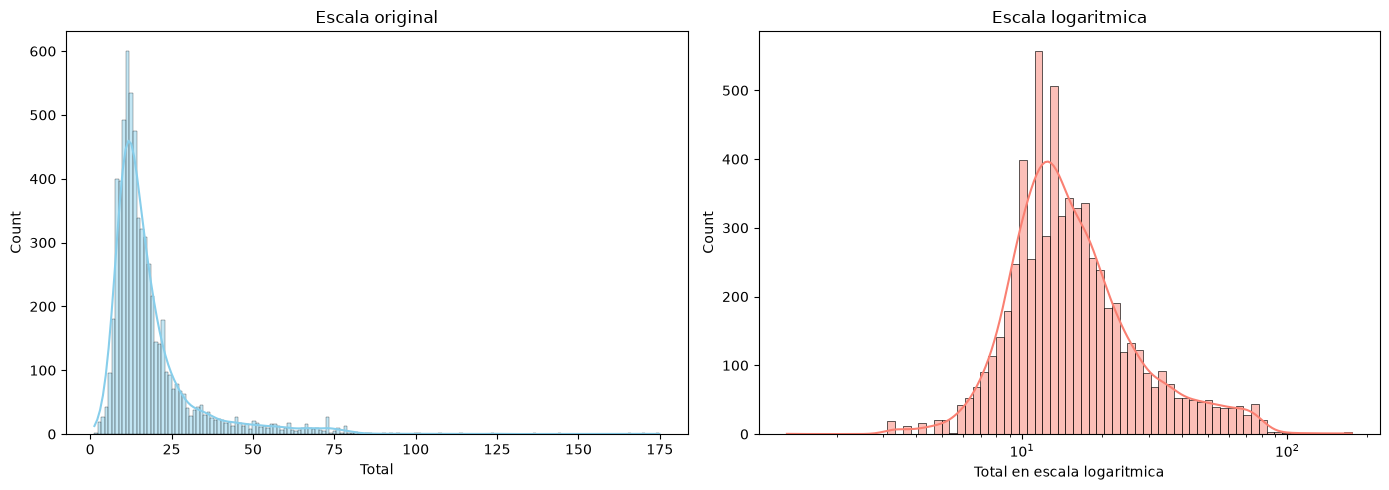

In [ ]:
# Create a histogram using Seaborn
#g = sns.histplot(data = taxis, x = 'total')

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(data = taxis,
                x = 'total',
                ax=axes[0],
                kde=True,
                color="skyblue") #con kde = true para poner la densidad. 
axes[0].set_title("Escala original")
axes[0].set_xlabel("Total")


sns.histplot(data = taxis,
                x = 'total',
                ax=axes[1],
                kde=True,
                color="salmon",
                log_scale=True)
axes[1].set_title("Escala logaritmica")
axes[1].set_xlabel("Total en escala logaritmica")

plt.tight_layout() # para ajustar espacios. 


Nota: Es importante usar siempre la escala logarítmica siempre que los datos tengan colas largas, además, en variables como precios, ingresos o salarios, población en ciudades o interacciones en redes sociales. 

La escala logarítmica permite analizar el comportaimento normal de los datos y ver de una manera más clara los atípicos. 

### **2. Diagrama de Caja:**

Los diagramas de caja son representaciones gráficas de la distribución de un conjunto de datos, pues muestran de forma simultánea la mediana, los cuartiles y el rango de datos. Son especialmente útiles para identificar valores atípicos.

![boxplot](https://miro.medium.com/max/9000/1*2c21SkzJMf3frPXPAR_gZA.png?raw=true&width=4&height=4)

Text(0.5, 0, 'Total paid per trip')

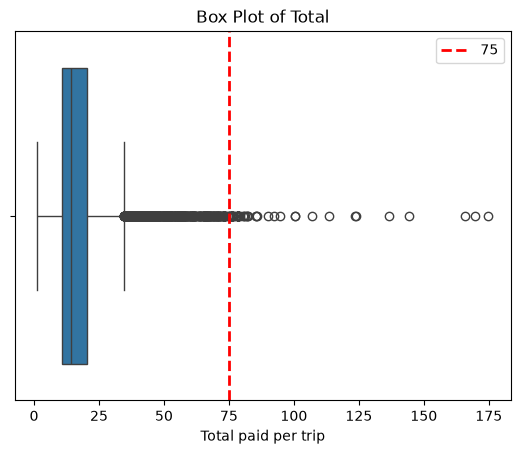

In [ ]:
# Create a box plot
g = sns.boxplot(data = taxis, x = 'total')

# Add a title and change xlabel
g.set_title('Box Plot of Total')
g.set_xlabel('Total paid per trip')

En el gráfico podemos ver claramente la presencia de outliers en la columna ‘total’, pero al igual que con el histograma, es recomendable acompañarlo de técnicas adicionales para determinar con exactitud la ubicación de estos valores atípicos.

### **3. Z-Score:**

Un Z-Score, también conocido como puntuación Z, es una medida estadística que indica cuántas desviaciones estándar un punto de datos específico está por encima o por debajo de la media del conjunto de datos.

En este sentido, podemos calcular la puntuación Z de cada dato usando la función zscore de scipy y compararla con un umbral para determinar qué valores son considerados atípicos. Por lo general se establece un umbral de 3, por lo que aquellos puntos de datos cuya puntuación Z absoluta sea superior a 3 son outliers.

In [33]:
# Import z-score function

#para usar el z-score hay que usarlo desde la libreria sicpy.stats
from scipy.stats import zscore
import numpy as np

# Calculate z-score for each data point and compute its absolute value
z_scores = zscore(taxis['total']) #z-score de la variable
abs_z_scores = np.abs(z_scores) #valos absoluto de la variable transformada. 

# Select the outliers using a threshold of 3
outliers = taxis[abs_z_scores > 3] #filtrar por los que sean mayor a 3. 
outliers.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
56,2019-03-05 17:57:00,2019-03-05 18:45:25,2,19.59,52.0,0.00,5.76,65.56,yellow,credit card,JFK Airport,Upper East Side North,Queens,Manhattan
162,2019-03-06 17:36:48,2019-03-06 18:43:39,2,17.10,52.0,13.10,5.76,78.66,yellow,credit card,Midtown South,JFK Airport,Manhattan,Queens
188,2019-03-26 15:06:47,2019-03-26 15:59:52,1,18.41,52.0,0.02,5.76,61.08,yellow,credit card,JFK Airport,Midtown Center,Queens,Manhattan
225,2019-03-22 15:36:34,2019-03-22 16:34:48,2,12.07,48.5,11.51,5.76,69.07,yellow,credit card,Manhattan Valley,Boerum Hill,Manhattan,Brooklyn


In [34]:
# Obtain number of outliers
print(f'Number of outliers: {len(outliers)}')


Number of outliers: 185


La elección del 3 como umbral proviene de la regla empírica, según la cual los datos dentro de 3 veces la desviación estándar respecto a la media representan el 99.7% de los datos de la distribución. Sabiendo esto, podemos concluir con bastante seguridad que los datos que caen más allá de este umbral son atípicos, pues son distintos al 99.7% de los datos.

![regla_empirica](https://datascience.eu/wp-content/uploads/2019/12/iStock-1213863214.jpg?raw=true&width=3&height=3)

En este caso encontramos 185 outliers usando el método del z-score, pero en realidad no podemos fiarnos de este resultado. ¿Por qué? Porque la regla empírica, y por tanto el método z-score, sólo es apropiada para distribuciones normales. Como vimos en el histograma, los datos para la variable ‘total’ están sesgados hacia la derecha por lo que debemos tomar otro enfoque.

## **4. Z-Score Modificado:**

Cuando los datos son asimétricos o no se distribuyen de forma normal podemos utilizar el z-score modificado, también conocido como MAD-Z-Score. Este, a diferencia del z-score, utiliza la mediana y la desviación absoluta mediana (MAD en inglés) en lugar de la media y la desviación estándar con el fin de evitar el efecto de los outliers sobre estas dos últimas medidas.

Por lo tanto, el z-score modificado mide cuánto se aleja un valor de la mediana en términos de la desviación absoluta mediana. Dicho de otra manera, nos indica cuántas desviaciones absolutas medianas, o MADs, se encuentra un punto de datos respecto a la mediana de la distribución.

En este contexto, se suele utilizar un umbral de 3.5 para considerar que un punto de datos es un outlier.

La función ‘median_abs_deviation’ de scipy nos permite calcular la desviación absoluta de la mediana (MAD), la cual podemos insertar luego en la fórmula para obtener la puntuación z modificada de cada dato. La fórmula está dada por:
$$
M_i =  \frac{{0.6745*(x_i-Mediana)}}{{MAD}}
$$

In [ ]:
# Import the median_abs_deviation function

#Calculamos el z-score modificado de una manera manual

#entonces primero hallamos el MAD gracias a scipy.stats
from scipy.stats import median_abs_deviation

# Obtain the MAD value, para la transfomación de los datos. 
mad_score = median_abs_deviation(taxis['total'])
mad_score

np.float64(4.199999999999999)

Sin embargo, la fórmula ya está implementada como el estimador MAD en la biblioteca PyOD, con lo cual no hace falta realizar el cálculo anterior. Podemos usarlo de la siguiente manera:

In [ ]:
print(taxis["total"].values.shape)

print(taxis["total"].values.reshape(-1,1).shape)

(6433,)
(6433, 1)


IMPORTANTE NOTA PARA LA FUNCIÓN: MAD  de pyod.models.mad

la librería pyod usa detrás Numba para acelerar los cálculos matemátcios. El problema es que Numba es estrcica con las versiones de Numpy compatibles, y las versiones modernas de Numpy cambiaron su arquitectura interna. 

Por tanto al hacer pip install numpy < 2.5 esto no existe formalmente en el canal oficial de PypPI. Para que Numba y PyOD funcionen se necesita a la rama ultra-estable 1.26.

forzando al entorno virtual instalar las versiones exactas que garantizan que PyOD, Numba y MAD se entiendan

`
# 1. Instalamos la versión más robusta y compatible de NumPy para Numba
pip install numpy==1.26.4 --force-reinstall

# 2. Actualizamos Numba y PyOD para asegurarnos de que se acoplen a esa versión
pip install --upgrade numba pyod
`
Al forzar a NumPy a bajar a la 1.26.4, Numba reconocerá inmediatamente el código base clásico de NumPy, dejará de protestar por el conflicto de importación y la función from pyod.models.mad import MAD cargará al instante en tu script o Jupyter Notebook sin lanzar ningún ImportError.


In [37]:
# Import MAD estimator
#la librería pyod ya tienen el MAD
from pyod.models.mad import MAD

#PYOD: python outlier detection

# Set threshold to 3.5
#Importamos el estimador y se define el umbral de 3.5
mad = MAD(threshold = 3.5)

# Convert the 'total' column into a 2D numpy array, 
#para convertirlo como en una matriz de los varios 
#registros y 1 variable. 
total_reshaped = taxis['total'].values.reshape(-1, 1)

# Generate inline and outlier labels
#Entrenamiento y clasificación.
#al ajustar con el .fit directamente el algoritmo
#calucula internamente la mediana de los montos totales 
#de los taxis y la MAD de esos datos. 
labels = mad.fit(total_reshaped).labels_
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(6433,))

$$M_i = \frac{0.6745(x_i-mediana)}{MAD}$$

Finalmente ".labels" compara cada valor con el puntaje crítico de 3.5 y le asigna la etiqueta 1 si no lo supera y 0 si lo supera. 

**labels** Es directamente un arreglo de Numpy lleno exclusivamente de ceros y unos, con la misma cantidad de registros del data set y clasifica a todos los puntos como atípicos o no. 


Comenzamos importando el estimador y estableciendo el umbral, que en este caso es de 3.5. El estimador calculará el z-score modificado y marcará cualquier punto que sobrepase de 3.5 como valor atípico.

Sin embargo, para poder usar el modelo con nuestros datos primero es necesario convertirlos en una matriz de dos dimensiones, como indica la [documentación](https://pyod.readthedocs.io/en/latest/pyod.models.html#module-pyod.models.mad) de PyOD.

Hecho esto, podemos usar el método ‘fit’ junto con el atributo ‘labels_’ para acceder a las etiquetas binarias generadas por el modelo, donde el estimador devuelve 0 para los inliners (valores no-atípicos) y 1 para los outliers.

Podemos usar estas etiquetas para contar el número de outliers detectados.

In [38]:
# Obtain number of outliers
print(f'Number of outliers: {labels.sum()}')

Number of outliers: 560


En este caso hemos identificado más outliers que con el método del z-score estándar. Podemos filtrar el dataset usando las etiquetas para obtener todos los registros con valores atípicos en la columna ‘total’ según el z-score modificado.

In [39]:
outliers = taxis.loc[labels == 1,]
outliers.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.00,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
22,2019-03-28 17:20:54,2019-03-28 17:55:57,1,9.82,31.5,8.31,5.76,49.87,yellow,credit card,LaGuardia Airport,Sutton Place/Turtle Bay North,Queens,Manhattan
40,2019-03-07 15:15:46,2019-03-07 15:50:14,1,7.51,27.0,6.06,0.00,36.36,yellow,credit card,Flatiron,Carroll Gardens,Manhattan,Brooklyn
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
53,2019-03-20 18:49:24,2019-03-20 19:12:40,1,13.45,36.0,0.00,0.00,37.80,yellow,cash,JFK Airport,Sunnyside,Queens,Queens


### **5. Rango Intercuartil (IQR)**

Otro método que podemos emplear si nuestros datos no siguen la distribución normal es el método del rango intercuartílico (IQR).

El IQR es una medida de dispersión que indica la distancia entre el primer cuartil (percentil 25) y el tercer cuartil (percentil 75) de una distribución. Puede utilizarse para identificar outliers al ayudar a definir los límites a partir de los cuales los valores se consideran atípicos. Estos límites se calculan de la siguiente manera:

Límite inferior = Q1 — (k * IQR)

Límite superior = Q3 + (k * IQR)

Donde Q1 es el primer cuartil y Q3 es el tercer cuartil. El valor más común del factor k es 1.5, aunque también se puede usar un factor de 3 o superior para identificar outliers extremos. Los valores que se encuentren por debajo del límite inferior o por encima del límite superior se consideran atípicos.

Podemos calcular los límites con la función ‘quantile’ y usarlos para filtrar el dataset:

In [40]:
# Calculate the percentiles
seventy_fifth = taxis['total'].quantile(0.75) #forma de calcular 3er cuartil
twenty_fifth = taxis['total'].quantile(0.25)

# Obtain IQR
iqr = seventy_fifth - twenty_fifth

# Upper and lower thresholds
upper = seventy_fifth + (1.5 * iqr)
lower = twenty_fifth - (1.5 * iqr)

# Subset the dataset
outliers = taxis[(taxis['total'] < lower) | (taxis['total'] > upper)]
outliers.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.00,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
22,2019-03-28 17:20:54,2019-03-28 17:55:57,1,9.82,31.5,8.31,5.76,49.87,yellow,credit card,LaGuardia Airport,Sutton Place/Turtle Bay North,Queens,Manhattan
40,2019-03-07 15:15:46,2019-03-07 15:50:14,1,7.51,27.0,6.06,0.00,36.36,yellow,credit card,Flatiron,Carroll Gardens,Manhattan,Brooklyn
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
43,2019-03-27 19:39:16,2019-03-27 20:00:26,1,9.50,28.0,0.00,5.76,35.06,yellow,cash,LaGuardia Airport,Washington Heights South,Queens,Manhattan


In [41]:
# Obtain number of outliers
print(f'Number of outliers: {len(outliers)}')

Number of outliers: 600


In [42]:
outliers.index

Index([   3,   22,   40,   42,   43,   53,   56,   92,  104,  111,
       ...
       6310, 6362, 6373, 6383, 6393, 6396, 6398, 6400, 6417, 6429],
      dtype='int64', length=600)

# ¿Cómo tratar los outliers?

Una vez identificados, debemos decidir qué hacer con ellos. Existen diferentes métodos para gestionarlos. La elección entre uno u otro dependerá del contexto y de los objetivos del análisis. Algunos de estos métodos son:


*   **1. Mantenerlos** — Podemos mantener los outliers si consideramos que pueden ser representativos de un subconjunto de nuestros datos, muchas veces el hecho de que sea atípico puede generar información importante.

*   **Eliminarlos** — Si estamos seguros de que los outliers provienen de un error en la entrada de los datos, como un error humano o de medida, y no podemos solucionarlo, podemos eliminarlos del conjunto de datos.

Para ello, podemos filtrar el dataset. Por ejemplo, en el caso del z-score modificado podemos usar las etiquetas para obtener los registros sin outliers.






In [43]:
taxis_filtered = taxis.copy()
taxis_filtered = taxis_filtered[labels == 0]



*   **Imputar** — La imputación implica reemplazar los valores atípicos con otros valores como la mediana o la media. Esto se suele hacer cuando queremos conservar la mayor cantidad de datos, pero eliminando el efecto de los outliers. Pero ojo, hay que manejarla con cuidado ya que puede cambiar la distribución original de los datos. 



In [44]:
# Calculate the median
median_value = taxis['total'].median()

# Impute outliers with the median
taxis_imputed = taxis.copy()
taxis_imputed.loc[outliers.index, 'total'] = median_value




*   **Winzorizar** — La winsorización es una técnica que reemplaza los valores atípicos por el valor más cercano que no se considera un outlier según ciertos criterios.

Por ejemplo, podemos reemplazar los valores atípicos por el valor del percentil 95 o 5 más cercano, reduciendo el efecto de los outliers sin eliminarlos por completo.

Es muy útil ya que no elimina los datos atípicos por completo pero si los reduce bastante. 



In [59]:
from scipy.stats.mstats import winsorize

taxis_winsorized = taxis.copy()
taxis_winsorized['total'] = winsorize(taxis_winsorized['total'],limits = [0.05, 0.05])
#Note que lo último dice que se cambie el 10% de los datos de tal manera que datos 
#atípicos menores se reemplazen por el valor del cuantil que deje un área a la izquierda
#de 0.05 y si es mayor que deje un área a la izquierda del 0.95. 

limits = [0.05, 0.05]: Establece los límites de winsorización para el 5% de los valores en ambos extremos de la distribución. Es decir, el 5% de los valores más bajos y el 5% de los valores más altos serán reemplazados por los valores en el percentil 5 y el percentil 95, respectivamente.

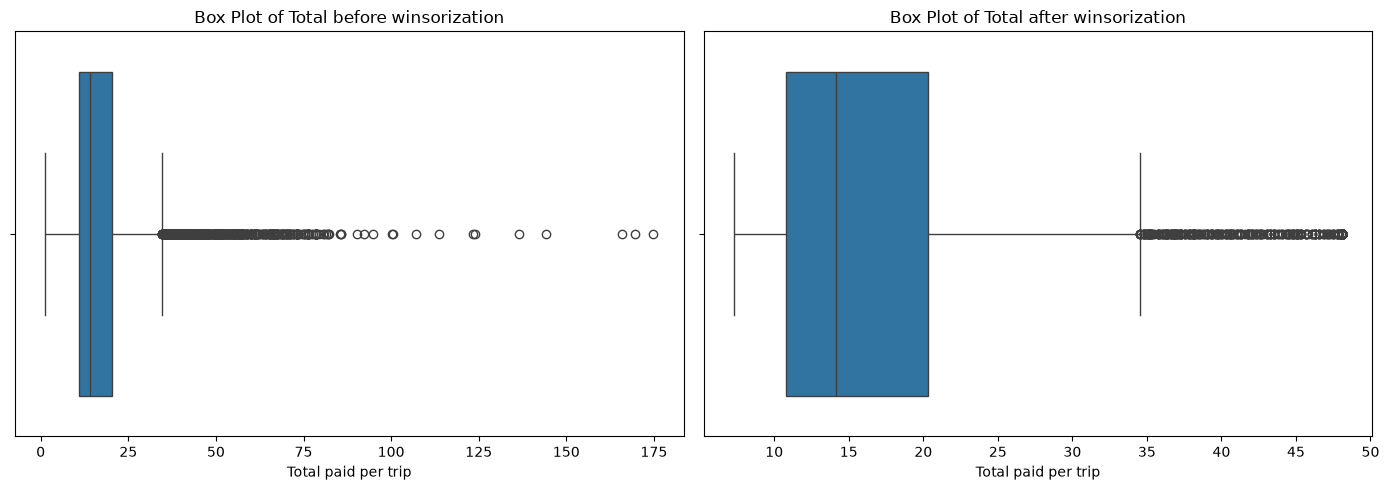

In [57]:
# Create a box plot

fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data = taxis, x = 'total',ax=axes[0])
# Add a title and change xlabel
axes[0].set_title('Box Plot of Total before winsorization')
axes[0].set_xlabel('Total paid per trip')

# Create a box plot
sns.boxplot(data = taxis_winsorized, x = 'total', ax=axes[1])

# Add a title and change xlabel
axes[1].set_title('Box Plot of Total after winsorization')
axes[1].set_xlabel('Total paid per trip')

plt.tight_layout() #para que la salida sea organizada


Nota: Ejercicio sacado de este [blog](https://medium.com/@martacasdelg/c%C3%B3mo-identificar-y-tratar-outliers-con-python-bf7dd530fc3).

## ***Detección de outliers Multivariados***

Para este enfoque, usaremos la base de datos StudentsPerformance.csv, la cual se puede descargar de la página de [kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download). También está disponible en el classroom del curso.

Aunque existen en la literatura varias alternativas para realizar la detección de datos atípicos a nivel multivariado, en esta sesión, nos concentraremos en las siguientes metodologías:



1.   **Distancia de Mahalanobis.**
2.   **Local Outlier Factor (LOF)**
3.   **Isolation Forest.**

En este [blog](https://panamahitek.com/identificacion-y-eliminacion-de-outliers-en-machine-learning/) se mencionan varias alternativas usando algoritmos de machine learning que sirven para la detección de puntos atípicos a nivel multivariado. Entre estas metodologías, se encuentran: métodos de clusterización (K-means, DBSCAN), métodos basados en redes neuronales, métodos basados en distancias (K-nearest neighbor, KNN), métodos de regresión.




### **Lectura de datos:**

In [96]:
import pandas as pd

# Lee el archivo CSV y carga los datos en un DataFrame
data = pd.read_csv("../../datos/StudentsPerformance.csv")

In [65]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Nota: La étnia y ese tipo de cosas son variables sensibles que el mundo de la analítica no deben usarse para modelar. 

Fairness: Es una politica de justicia dentro del modelo para que no haya discriminación a minorias ni sesgos a grupos culturales. La idea es eliminar ese sesgo que hay en el mundo a los modelos. 

In [67]:
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

### ¿Y si obtenemos baja calificación en dos materias pero alta en matemáticas?

En este paso, creo artificialmente dos puntos atípicos, en los que se tiene una calificación en matemáticas alta y en el resto baja.

In [98]:
# Filtramos los casos donde obtuvimos baja calificación en dos materias pero alta en Matemáticas
data.loc[(data['math score'] == 19) & (data['writing score'] == 32), 'math score'] = 80
data.loc[(data['math score'] == 18) & (data['reading score'] == 32), 'math score'] = 82

In [99]:
data.loc[data['writing score'] == 32,]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
363,female,group D,some high school,free/reduced,none,27,34,32
787,female,group B,some college,standard,none,80,38,32


A continuación, se guardan los nombres de los registros modificados, con el fin de identificarlos y posteriormente graficarlos.

In [102]:
# Guardamos los nombres de los registros modificados
modificados_df = data[((data['math score'] == 80) & (data['writing score'] == 32)) | ((data['math score'] == 82) & (data['reading score'] == 32))]


In [105]:
print(modificados_df)
print(modificados_df.index)
modificados = modificados_df.index

     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
787  female        group B                some college      standard   

    test preparation course  math score  reading score  writing score  
17                     none          82             32             28  
787                    none          80             38             32  
RangeIndex(start=17, stop=1557, step=770)


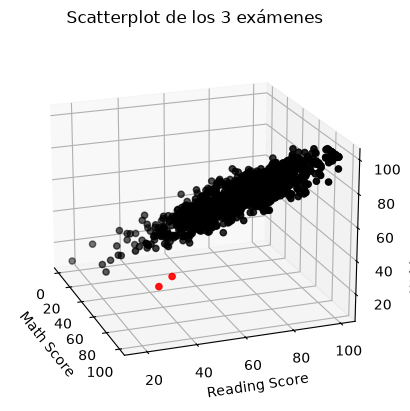

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Observamos los 3 exámenes en un scatterplot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#en rojo serán las observaciones atípicas que creamos. 
ax.scatter(data['math score'], data['reading score'], data['writing score'], c=['red' if index in modificados else 'black' for index in data.index])
ax.set_xlabel('Math Score')
ax.set_ylabel('Reading Score')
ax.set_zlabel('Writing Score')
ax.set_title('Scatterplot de los 3 exámenes')
# Puedes ajustar el ángulo de visualización utilizando view_init
# El primer argumento es el ángulo de elevación (elevación hacia arriba o hacia abajo)
# El segundo argumento es el ángulo azimutal (rotación horizontal)
ax.view_init(elev=20, azim=-20)
plt.show()

Para el análisis de datos atípicos a nivel multivariado, se creará un nuevo dataframe (df_selected) que contiene sólo las columnas de las variables con las que realizamos el análisis:

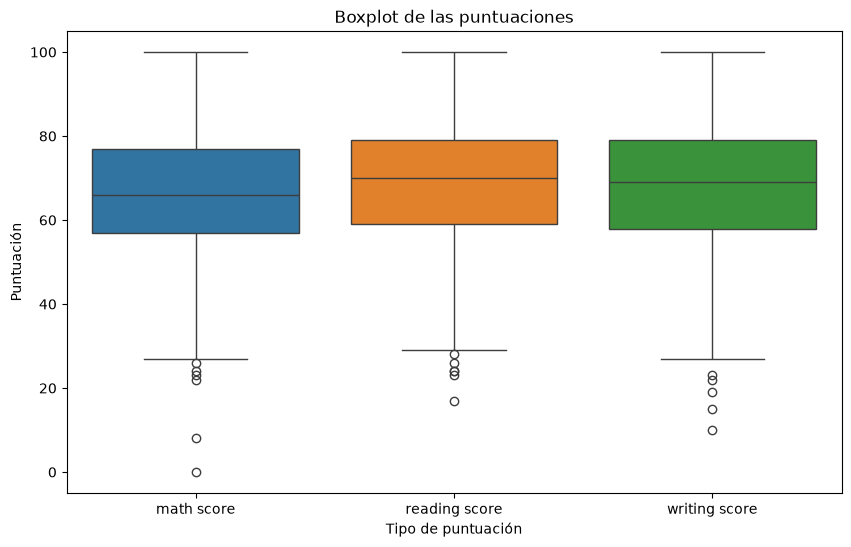

In [107]:
# Seleccionamos solo las tres columnas de interés
df_selected = data[['math score', 'reading score', 'writing score']]

# Creamos el gráfico de caja
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_selected)
plt.title('Boxplot de las puntuaciones')
plt.xlabel('Tipo de puntuación')
plt.ylabel('Puntuación')
plt.show()

In [109]:
df_selected.values

array([[72, 72, 74],
       [69, 90, 88],
       [90, 95, 93],
       ...,
       [59, 71, 65],
       [68, 78, 77],
       [77, 86, 86]], shape=(1000, 3))

## **1. Distancia de Mahalanobis:**

Es una medida de distancia entre el punto $\vec{x}=(x_1,x_2,x_3)$ y el vector de medias $\vec{\mu}=(\mu_1,\mu_2,\mu_3)$, teniendo en cuenta la matriz de varianzas y covarianzas $S$. La distancia de Mahalanobis se define como:

$$
D_{M}(\vec{x})=\sqrt{(\vec{x}-\vec{\mu})^TS^{-1}(\vec{x}-\vec{\mu})}
$$

In [32]:
from scipy.spatial import distance

#distance es la instancia para los tipos de distancias que hay
#en este caso se usa la de Mahalanobis. 

# Calculamos la matriz de covarianza de las variables
cov_matrix = np.cov(df_selected, rowvar=False)

# Calculamos la inversa de la matriz de covarianza
cov_inv = np.linalg.inv(cov_matrix)

# Calculamos la distancia de Mahalanobis para cada fila en el DataFrame
dist_mahalanobis = []
for row in df_selected.values:
    dist = distance.mahalanobis(row, df_selected.mean(), cov_inv)
    dist_mahalanobis.append(dist)

# Agregamos la distancia de Mahalanobis como una nueva columna en el DataFrame
data['mahalanobis_distance'] = dist_mahalanobis

# Mostramos el DataFrame con la distancia de Mahalanobis
print(data)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  \
0                      none          72             72        

In [33]:
# Ordenamos el DataFrame por la columna de distancia de Mahalanobis en orden descendente
df_sorted = data.sort_values(by='mahalanobis_distance', ascending=False)

# Seleccionamos los primeros tres registros con las distancias más grandes
df_sorted.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mahalanobis_distance
17,female,group B,some high school,free/reduced,none,82,32,28,5.961280
787,female,group B,some college,standard,none,80,38,32,5.200889
59,female,group C,some high school,free/reduced,none,0,17,10,4.538677


Recordemos que para este tipo de métodos de identificación de datos atípicos no hay como un número o valor para poder comparar si un dato es atípico o no, acá, lo que se puede hacer es ordenar y ver los datos que tengan la distancia de Mahalanobis más grande que haya. 

Y como se puede observar, están los datos genreados por nosotros, por lo que con este método es claro que si se identifican como atípicos. 

## **2. Local Ourlier Factor:**

Local outlier factor es un método basado en **densidad** que utiliza la búsqueda de vecinos más cercanos. Ese método calcula los **scores** para cada uno de los puntos a partir de la tasa promedio de densidad de los puntos vecinos con respecto a si mismo.

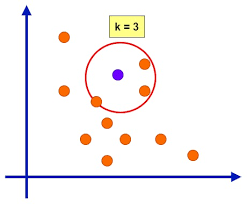

Al ajustar el modelo, el algoritmo calcula por defecto para un valor de K=20 pero esto puede cambiarse.

In [110]:
#LOF sale directamente de sickit learn. 
from sklearn.neighbors import LocalOutlierFactor

# Calculamos el LOF para las tres variables
lof = LocalOutlierFactor() #instancia de LOF
lof.fit_predict(df_selected)# se ajusta la instancia, 
#es decir, acá se obtiene el LOF para cada observación

# Obtenemos los scores LOF para cada punto
scores_lof = -lof.negative_outlier_factor_
#acá obtuvimos las lof, que por defecto los da negativos
#entonces por eso se multiplican por -1. 

# Agregamos los scores LOF como una nueva columna en el DataFrame
data['lof_score'] = scores_lof

# Mostramos el DataFrame con los scores LOF
print(data)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  \
0                      none          72             72        

In [111]:
data["lof_score"]

0      1.012512
1      1.199068
2      0.997746
3      1.263286
4      0.975059
         ...   
995    1.010623
996    0.988801
997    1.058787
998    0.969869
999    0.971704
Name: lof_score, Length: 1000, dtype: float64

si se quiere modificar el valor de K, se puede definir de la siguiente manera:

In [112]:
# Definimos el valor de k
k = 5

# Calculamos el LOF para las tres variables con el valor de k especificado
lof = LocalOutlierFactor(n_neighbors=k)
lof.fit_predict(df_selected)

#notese que le propio método también tiene un criterio
#para definir si un dato es atípico o no y pues hay que revisarlo desde 
#la documentación para ver como es. Para ver como crea las etiquetas 
#de atípico o no atipico. 

array([ 1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [114]:
# Ordenamos el DataFrame por la columna 'lof_score' en orden descendente
df_sorted = data.sort_values(by='lof_score', ascending=False)

# Seleccionamos los primeros tres registros con los scores LOF más grandes
primeros_tres_lof = df_sorted.head(3)

In [115]:
primeros_tres_lof

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,lof_score
17,female,group B,some high school,free/reduced,none,82,32,28,3.633010
787,female,group B,some college,standard,none,80,38,32,3.250833
59,female,group C,some high school,free/reduced,none,0,17,10,2.738440


Igualmente, se lográn identificar los datos atípicos con este método. 

### **3. Isolation Forest:**
Las instancias de datos anómalos se pueden aislar de los datos normales mediante la partición recursiva del conjunto de datos.

![isolation](https://miro.medium.com/v2/resize:fit:1174/1*-TANPVnrnxPo-p2cnZpPHQ.png)

Recordemos que a menos cortes, es porque es más facil serparar los datos y por tanto es fácil identificar los atípicos. Ojo, este método soporta variables categóricas. 


In [117]:
from sklearn.ensemble import IsolationForest

#función dentro de sklearn.ensemble. 

# Definimos la cantidad de árboles
n_arboles = 250 #por defecto es 100 y toma 256 datos
#en este caso no se edita la cantidad de datos de muestreo. 

#con toda la cantidad de árboles se contruye el bosque. 
#Ojo, esto es pesado computacionalmente. 

# Inicializamos y ajustamos el modelo Isolation Forest con la cantidad de árboles especificada

#INSTANCIA DEL MODELO DE MACHINE LEARNING COMO OBJETO
isolation_forest = IsolationForest(n_estimators=n_arboles, random_state=42) # se define una instancia de un modelo
#de isolation forest. 

#random_state: es la semilla. 

#ENTRENAMIENTO DEL MODELO DE MACHINE LEARNIG
puntajes_anomalia = isolation_forest.fit(df_selected) #entreno del modelo

# Obtenemos los puntajes de anomalía para cada muestra
#MEDICIÓN DE LA CANTIDAD DE PASOS PARA AISLAR UN OBJETO.
puntajes_anomalia = isolation_forest.score_samples(df_selected)

# Convertimos los puntajes de anomalía a valores positivos
puntajes_anomalia = -puntajes_anomalia

# Obtenemos las etiquetas de anomalía (inlier/outlier) para cada punto
#etiquetas_anomalia = isolation_forest.predict(df_selected)

# Agregamos las etiquetas de anomalía como una nueva columna en el DataFrame
data['puntajes_anomalia'] = puntajes_anomalia

Este algoritmo soporta variables categóricas, sin embargo, se mantuvo el análisis sbore variables de calificaciones para obtener resultados comparables.

In [118]:
# Ordenamos el DataFrame por los puntajes de anomalía en orden descendente
df_sorted = data.sort_values(by='puntajes_anomalia', ascending=False)

# Seleccionamos los primeros tres registros con los puntajes de anomalía más altos
primeros_tres_anomalies = df_sorted.head(3)
print(primeros_tres_anomalies)

     gender race/ethnicity parental level of education         lunch  \
59   female        group C            some high school  free/reduced   
980  female        group B                 high school  free/reduced   
327    male        group A                some college  free/reduced   

    test preparation course  math score  reading score  writing score  \
59                     none           0             17             10   
980                    none           8             24             23   
327                    none          28             23             19   

     lof_score  puntajes_anomalia  
59    2.738440           0.771966  
980   1.909518           0.749150  
327   1.642621           0.730585  


### Nota: Machine learning en python como objetos

En las librerías como scikit-learn y PyoD, los modelos de machine learning funcionan estrictamente com objetos bajo el paradigma de programación orientada a objetos POO.

Cuando se importa un modelo, por ejemplo 

```python
from pyod.models.mad import MAD
```

Lo que se esta importando es una Clase (Plantilla o el plano arquitectónico del modelo). Para poder usarlo con tus propios datos, necesitas crear una instancia de la clase o objeto. 

Cada instancia guarda sus propios hiperparámetros por lo que se pueden tener diferentes objetos (modelos) con distintos hiperparámetros para ser ajustados y poder compararlos. 

Además, cuando se ejecuta del método 

```python
.fit(datos)
```
El modelo analiza tus datos y aprende algo de ellos. Ese conocimento se tiene que guardar dentro del mismo objeto. 

Finalmente, gracias al polimorfismo se tienen los mismos métodos para los distintos tipos de modelos por ejemplo

```python
.fit() # Para entrenar el modelo
.predict() # Para tomar una decisión
```

Gracias a su comportamiento como objetos , cambiar el algoritmo es fácil. 